In [1]:
from plotter import Plotter
viz = Plotter("data/round3")

In [26]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [14]:
t = 2

row = viz.prices[(viz.prices["product"] == "VELVETFRUIT_EXTRACT") & (viz.prices["timestamp"] == t*100)]
print(row)

    day  timestamp              product  bid_price_1  bid_volume_1  \
25    0        200  VELVETFRUIT_EXTRACT         5248            20   

    bid_price_2  bid_volume_2  bid_price_3  bid_volume_3  ask_price_1  \
25       5247.0          40.0          NaN           NaN         5253   

    ask_volume_1  ask_price_2  ask_volume_2  ask_price_3  ask_volume_3  \
25            60          NaN           NaN          NaN           NaN   

    mid_price  profit_and_loss  
25     5250.5              0.0  


In [13]:
viz.prices

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,25,NaN,NaN,NaN,NaN,23.0,0.0
1,0,0,VEV_6500,0,16,NaN,NaN,NaN,NaN,1,16,NaN,NaN,NaN,NaN,0.5,0.0
2,0,0,VEV_5500,8,25,NaN,NaN,NaN,NaN,9,25,NaN,NaN,NaN,NaN,8.5,0.0
3,0,0,VEV_5200,100,19,NaN,NaN,NaN,NaN,103,6,104.0,13.0,NaN,NaN,101.5,0.0
4,0,0,VEV_5300,52,6,51.0,19.0,NaN,NaN,54,25,NaN,NaN,NaN,NaN,53.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359995,2,2999900,VELVETFRUIT_EXTRACT,5293,25,5292.0,39.0,NaN,NaN,5298,64,NaN,NaN,NaN,NaN,5295.5,0.0
359996,2,2999900,VEV_4500,787,10,785.0,17.0,NaN,NaN,804,10,806.0,17.0,NaN,NaN,795.5,0.0
359997,2,2999900,VEV_5400,19,28,NaN,NaN,NaN,NaN,21,28,NaN,NaN,NaN,NaN,20.0,0.0
359998,2,2999900,VEV_6500,0,11,NaN,NaN,NaN,NaN,1,11,NaN,NaN,NaN,NaN,0.5,0.0


In [22]:
lasts = list(viz.trades[viz.trades["product"] == "VELVETFRUIT_EXTRACT"]["price"])
lasts[:5]

[5250.0, 5236.0, 5241.0, 5229.0, 5237.0]

In [37]:
und_prices = viz.prices[viz.prices["product"] == "VELVETFRUIT_EXTRACT"]
mids = list(((und_prices["bid_price_1"] + und_prices["ask_price_1"])/2).dropna())
mids[:5]

[5250.0, 5250.5, 5250.5, 5250.5, 5250.5]

In [53]:
def test_revert(prices, lag):
    x = prices[:-lag]
    y = [curr-prev for curr, prev in zip(prices[lag:], prices[:-lag])]

    r, p = pearsonr(x, y)
    print(f"r = {r:.4f}, p = {p:.4g}")

    plt.scatter(x, y, s=4, alpha=0.3)
    plt.show()

r = -0.7478, p = 0


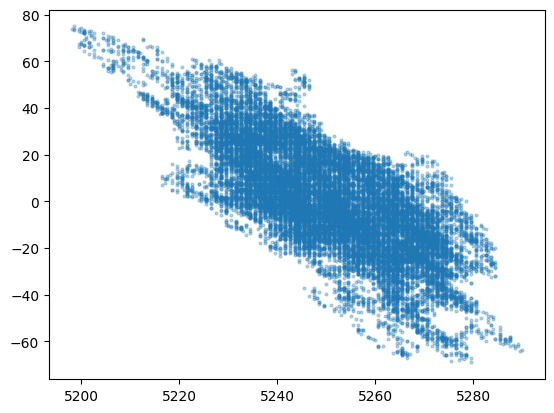

In [58]:
test_revert(mids, lag=5000)

r = -0.7023, p = 1.694e-167


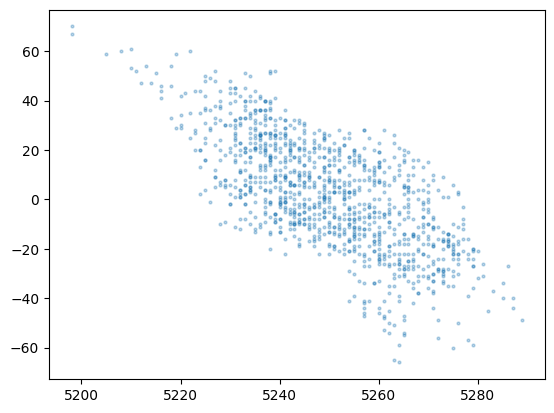

In [59]:
test_revert(lasts, lag=250)